# GEOG 412: Programming for Geospatial Data Science, Unit 3

## Assignment 3: Programmatic Data Processing and Mapping

For this assignment, you will...

*   Complete a series of five data processing exercises designed to help you practice basic data processing techniques with *pandas* in a targeted manner (ten points altogether);
*   Complete one more complicated exercise that requires you to creatively apply what you have learned about the logic and syntax of Python programming in a less structured manner (ten points).



Your code should be written directly within a copy of this notebook, and you should upload a copy of your notebook to the course website as you have done for previous assignments.

**To begin, choose "Save a copy in Drive" from the File menu to create your own copy of this notebook.**

In [ ]:
!pip install geopandas mapclassify

## Data Processing Exercises

Each one of these exercises will involve practicing specific elements of the data processing techniques that are covered in this unit.  These exercises are designed to ensure that you are familiar with common methods associated with the DataFrame class in *pandas*.

**Please note that all of these exercises require use of the data layer "counties" within the data file "election_2020.gpkg".**  This data file, which contains the results of the 2020 U.S. presidential election, is available for download on the course website.

###Exercise 1 (one point)

Use pandas to obtain the mean and median values of percent margin of vote share separating Biden and Trump.  Note that positive values favor Trump, and negative margins favor Biden.

In [ ]:
# Code for exercise 1 goes here

import pandas as pd
import geopandas as gpd

gpkg_path = 'election_2020.gpkg'
county = gpd.read_file(gpkg_path,layer='county')
state = gpd.read_file(gpkg_path,layer='state')

print(
    "Mean Pct Margin by County: ",
    county['P_MARGIN'].mean())
print(
    "Median Pct Margin by County: ",
    county['P_MARGIN'].median())
print(
    "Mean Pct Margin by State: ",
    state['P_MARGIN'].mean())
print(
    "Median Pct Margin by State: ",
    state['P_MARGIN'].median())

###Exercise 2  (one point)

Use pandas to obtain the median values of all numeric columns in the dataframe, grouped by state.

In [ ]:
# Code for exercise 2 goes here

import pandas as pd
import geopandas as gpd

gpkg_path = 'election_2020.gpkg'
state = gpd.read_file(gpkg_path,layer='state')

state.groupby('STATE_NAME').median()

###Exercise 3  (two points)

Use pandas to filter the dataset to include only the counties within the state of Colorado, and then create a simple choropleth map of one of the vote share variables.

In [ ]:
# Code for exercise 3 goes here

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as cl
import mapclassify

gpkg_path = 'election_2020.gpkg'
county = gpd.read_file(gpkg_path,layer='county')
state = gpd.read_file(gpkg_path,layer='state')

county_colorado = county[county['STATE_NAME'] == 'Colorado']

fig, ax = plt.subplots(figsize=(16,8))
ax.set_title('2020 U.S. Presidential Election - Republican Vote Share in Colorado',fontsize=24)
ax.set_axis_off()

county_colorado.plot(
    ax=ax,
    column='P_TRUMP',
    legend=True,
    cmap='Reds',
    figsize=(16,8),
    scheme='NaturalBreaks',
    k=5,
    legend_kwds={'loc':'lower left'}
)

###Exercise 4 (two points)

Use pandas to create a new boolean field indicating whether or not a county was won by President Biden, and make a choropleth map of the field's values.

In [ ]:
# Code for exercise 4 goes here

import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as cl
import mapclassify

gpkg_path = 'election_2020.gpkg'
county = gpd.read_file(gpkg_path,layer='county')

county['biden_win'] = np.where(county['V_MARGIN'] < 0, True, False)

red_blue = cl.ListedColormap(['red','blue'])

fig, ax = plt.subplots(figsize=(16,8))
ax.set_title('2020 U.S. Presidential Election - Biden Counties',fontsize=24)
ax.set_axis_off()

county.plot(
    ax=ax,
    column='biden_win',
    categorical=True,
    legend=True,
    cmap=red_blue,
    figsize=(16,8),
    legend_kwds={'loc':'lower left'}
)

###Exercise 5  (four points)

The following URL points to a CSV file that contains cumulative COVID-19 cases and deaths at the county level, published by the New York Times:  https://raw.githubusercontent.com/nytimes/covid-19-data/master/us-counties-recent.csv

Using pandas, load the CSV as a dataframe, filter it to show only the most recent available data (i.e., choose the most recent date and filter by it), create a new field corresponding to deaths per 100,000 residents, merge this data with the counties GeoDataFrame using FIPS codes as key fields, and then display a choropleth map of this field.

In [ ]:
# Code for exercise 5 goes here

import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as cl
import mapclassify

csv_path = 'us-counties-recent.csv'
gpkg_path = 'election_2020.gpkg'

county_fm_csv = gpd.read_file(csv_path) # also tried pd.read_csv; this works better
county = gpd.read_file(gpkg_path,layer='county')

csv_latest = county_fm_csv[county_fm_csv['date'] == '2023-03-23'] # filter to most recent date

county = county.merge(csv_latest,left_on="FIPS_NUM",right_on='fips') # join csv data including deaths to county gdf

county['deaths_p_100k'] = county['deaths'].astype(float) * 100000 / county['TOTPOP'].astype(float)

county.plot(
      column='deaths_p_100k',
      cmap='Reds',
      legend=True,
      figsize=(16,6)
) # why is this producing a histogram ? why does legend contain all values ? 'county' dataframe seems to still contain geometry

##Python Programming Challenge

This challenging exercise is designed to put your new Python programming skills to the test.  As you complete this exercise you will need to carefully think about not only the specific techniques that you will need to use to write code that meets the requirements of the challenges, but also the logical sequences and control flow that are required in order for your script to function properly.  Don't be afraid to get creative, and make sure to test your script thoroughly before submitting.

###Economic and Demographic Data Mapping Tool

For this week's assignment, you will develop a program that generates a data dashboard containing choropleth maps and histograms based on demographic and economic data obtained on-the-fly from the World Bank's Indicators API.  More specifically, you will create a script that draws customizable maps based on selections that users will make using drop-down menus.

Your program must include the following elements:

*   At least five appropriate sequential color schemes must be provided in a drop-down menu. [(Which color schemes are available?)](https://matplotlib.org/stable/tutorials/colors/colormaps.html)
*   A drop-down menu or slider for selecting data year should also be included, and at least five different years supported by the World Bank API must be included.
*   Users should be able to select from among at least ten different data variables using a drop-down menu.  The menu options should include descriptive names for the variables. [(Which variables are available?)](https://data.worldbank.org/indicator)

When the user changes any one of the dropdown menus, a choropleth map and histogram should be drawn of the selected data.  Any previously drawn maps and charts should also be cleared when a dropdown is changed.

*BONUS (not required):  Incorporate one or more additional visualizations!*

Upon completion, your dashboard should resemble this screenshot:

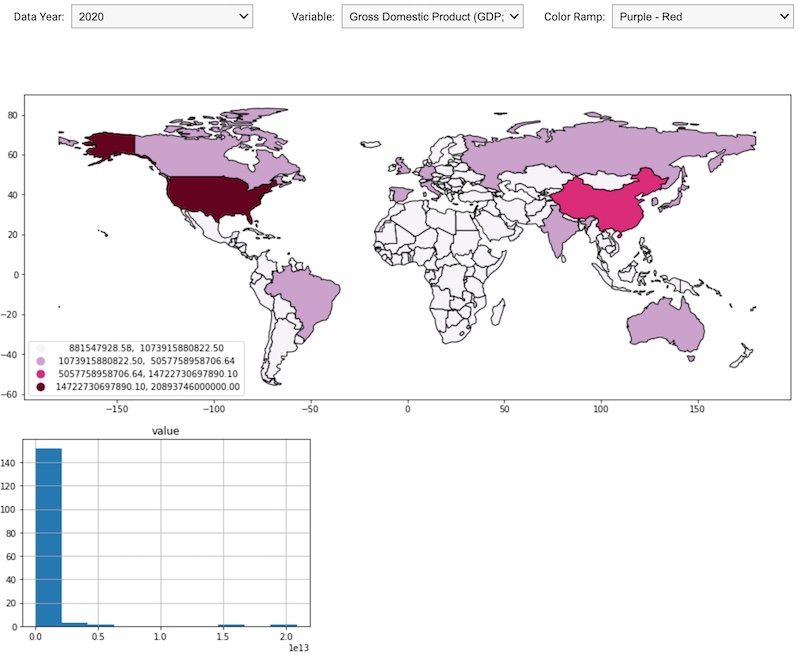

GeoPandas and mapclassify must be installed for this script, so it is advisable to run the installation when needed in the following separate code block...

In [ ]:
import requests
import pandas as pd
import geopandas as gpd
import numpy as np
import mapclassify
import matplotlib.pyplot as plt
import matplotlib.colors as cl
import ipywidgets as widgets
from IPython.display import display, clear_output

# variable selections, global variables

year_options = [2020,2019,2018,2016,2009]
variable_options = [('Urban Population, %/total','SP.URB.TOTL.IN.ZS'),
  ('Rural Population, %/total','SP.RUR.TOTL.ZS'),
  ('Male labor force participation, %/male pop','SL.TLF.CACT.MA.ZS'),
  ('Female labor force participation, %/female pop','SL.TLF.CACT.FE.ZS'),
  ('Poverty headcount ratio at national poverty lines, %/population','SI.POV.NAHC'),
  ('crude birth rate, /1k people','SP.DYN.CBRT.IN'),
  ('crude death rate, /1k people','SP.DYN.CDRT.IN'),
  ('government expenditure on education, %/GDP','SE.XPD.TOTL.GD.ZS'),
  ('military expenditure, %/GDP','MS.MIL.XPND.GD.ZS'),
  ('research and development expenditure, %/GDP','GB.XPD.RSDV.GD.ZSN')]
color_options = ['Greys','Reds','Greens','Blues','Purples']

# dropdown selectors

year_dropdown = widgets.Dropdown(options=year_options,description='Year:',disabled=False)
variable_dropdown = widgets.Dropdown(options=variable_options,description='Variable:',disabled=False)
color_dropdown = widgets.Dropdown(options=color_options,description='Color:',disabled=False,)

# grid

grid = widgets.GridspecLayout(1,3,height='60px')
grid[0,0] = year_dropdown
grid[0,1] = variable_dropdown
grid[0,2] = color_dropdown

# on change event / function

def on_change(event=None):
  clear_output()
  countries = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
  clear_output()
  print("Selected year: ",year_dropdown.value)
  print("Selected variable: ",variable_dropdown.value)
  print("Selected color scheme: ",color_dropdown.value)
  display(grid)
  r_url = 'https://api.worldbank.org/v2/country/all/indicator/{}?format=json&per_page=500&date={}'.format(variable_dropdown.value,year_dropdown.value)
  r = requests.get(r_url)
  r_json = r.json()
  r_json = r_json[1]

  df = pd.DataFrame(r_json)
  df_subset = df[['countryiso3code','value']]
  countries_joined = countries.merge(df_subset,left_on='iso_a3',right_on='countryiso3code')

  fig, ax = plt.subplots(figsize=(16,6))
  ax.set_title(str(variable_dropdown.value) + ', ' + str(year_dropdown.value),fontsize=24) # not sure how to get title to read as description instead of value, i.e. 'Total Population' vs 'SP.POP.TOTL'
  ax.set_axis_off()
  countries_joined.plot(
      ax=ax,
      column='value',
      cmap=color_dropdown.value,
      legend=True,
      figsize=(16,6))

  countries_joined.hist(
      column='value',
      figsize=(14,6))

# observe

year_dropdown.observe(on_change,names='value')
variable_dropdown.observe(on_change,names='value')
color_dropdown.observe(on_change,names='value')

# start

display(grid)

ModuleNotFoundError: No module named 'mapclassify'